# Árbol de Decisión CART — Clasificación Binaria de Nivel de Poder

Construcción, entrenamiento y evaluación de un modelo de Árbol de Decisión CART para predecir
si un superhéroe posee un nivel de poder alto.

| | |
|---|---|
| **Variable objetivo (Y)** | es_poder_alto (1 = Poder alto, 0 = Poder medio/bajo) |
| **Variables predictoras (X)** | fuerza, inteligencia, velocidad, durabilidad, combate |
| **Modelo** | DecisionTreeClassifier — criterio Gini (CART, scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 70/30 · 60/40 + ajuste de max_depth |

> **Origen de datos** — dataset de superhéroes almacenado en PostgreSQL y previamente limpio/imputado.
> A diferencia de la regresión lineal, el árbol CART no asume relaciones lineales,
no requiere escalado de variables y permite capturar interacciones no lineales entre habilidades.

## CELDA 1: Configuración Inicial — Importaciones y Estilo Visual

In [25]:
# ── CELDA 1: Importaciones (CART) ────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️ Nota: El árbol CART NO requiere normalización (MinMaxScaler no se usa)")


✅ Librerías importadas correctamente
   pandas   2.2.0
   numpy    1.26.4
   seaborn  0.13.2

⚠️ Nota: El árbol CART NO requiere normalización (MinMaxScaler no se usa)


## CELDA 2: Extracción de Datos desde PostgreSQL

Se realiza la consulta a la base de datos PostgreSQL para obtener el dataset de superhéroes junto con sus atributos principales. 
Durante esta extracción, se genera directamente la variable objetivo binaria 

`es_poder_alto` mediante una instrucción `CASE WHEN`, clasificando a los personajes según su nivel de poder.

**De esta forma:**
- Se evita procesamiento adicional fuera de la base de datos.
- Se asegura consistencia en la definición de la variable objetivo
- Se mantiene la trazabilidad del pipeline de análisis

In [26]:
# ── CELDA 2: Extracción SQL ─────────────────────────────────────────────────
QUERY = """
SELECT
    s.id,
    s.nombre,
    s.editorial,

    AVG(p.inteligencia) AS inteligencia,
    AVG(p.fuerza)       AS fuerza,
    AVG(p.velocidad)    AS velocidad,
    AVG(p.durabilidad)  AS durabilidad,
    AVG(p.poder)        AS poder,
    AVG(p.combate)      AS combate,

    CASE
        WHEN AVG(p.poder) >= 73 THEN 1
        ELSE 0
    END AS es_poder_alto

FROM superheroes s
JOIN powerstats p 
    ON s.id = p.superhero_id

WHERE s.activo = true

GROUP BY s.id, s.nombre, s.editorial;
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Columnas:")
print(df.columns.tolist())

print("\n⚖️ Balance de la variable objetivo:")
bal = df['es_poder_alto'].value_counts()
pct = df['es_poder_alto'].value_counts(normalize=True) * 100

print(f"   Poder alto (1): {bal.get(1,0):,} ({pct.get(1,0):.1f}%)")
print(f"   Poder bajo (0): {bal.get(0,0):,} ({pct.get(0,0):.1f}%)")

print("\n📋 Primeras filas:")
df.head()


✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 14
   Columnas : 10

📋 Columnas:
['id', 'nombre', 'editorial', 'inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate', 'es_poder_alto']

⚖️ Balance de la variable objetivo:
   Poder alto (1): 7 (50.0%)
   Poder bajo (0): 7 (50.0%)

📋 Primeras filas:


,id,nombre,editorial,inteligencia,fuerza,velocidad,durabilidad,poder,combate,es_poder_alto
0,4,Hulk,None,77.400826,52.000000,65.053719,69.599174,67.061983,93.206612,0
1,14,Captain Marvel II,None,90.221790,65.836576,52.832685,71.132296,71.988327,84.852140,0
2,3,Wonder Woman,None,86.948905,67.062044,90.043796,61.704380,74.791971,60.306569,1
3,13,Captain Marvel,None,52.823293,92.622490,70.128514,89.726908,76.188755,80.192771,1
4,10,Captain Mar-vell,None,74.738281,89.140625,52.394531,88.265625,77.351562,86.921875,1



# CELDA 3 Validación y Exploración del Dataset

En esta sección se realiza una revisión inicial del dataset obtenido desde PostgreSQL con el objetivo de verificar su estructura, calidad y consistencia.

Se analizan:
- Tipos de datos de cada variable
- Presencia de valores nulos
- Balance de la variable objetivo `es_poder_alto`
- Distribución de los registros

Este paso es fundamental para asegurar que los datos están en condiciones adecuadas antes de entrenar el modelo de clasificación.


In [27]:
# ── CELDA 3: Validación y Exploración ───────────────────────────────────────

print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df.dtypes.to_frame('dtype').join(
    df.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df['es_poder_alto'].value_counts()
pct     = df['es_poder_alto'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Poder alto (1): {balance.get(1,0):>5,}  ({pct.get(1,0):.1f}%)")
print(f"   Poder bajo (0): {balance.get(0,0):>5,}  ({pct.get(0,0):.1f}%)")

# Distribución por superhéroe
print(f"\n🦸 Distribución por superhéroe:")
print(df['nombre'].value_counts().to_string())


VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                 dtype  nulos
id               int64      0
nombre          object      0
editorial       object     14
inteligencia   float64      0
fuerza         float64      0
velocidad      float64      0
durabilidad    float64      0
poder          float64      0
combate        float64      0
es_poder_alto    int64      0

🎯 Balance de la variable objetivo:
   Poder alto (1):     7  (50.0%)
   Poder bajo (0):     7  (50.0%)

🦸 Distribución por superhéroe:
nombre
Captain Marvel       2
Hulk                 1
Captain Marvel II    1
Wonder Woman         1
Captain Mar-vell     1
Captain Epic         1
Captain Midnight     1
Flash                1
Spider-Man           1
Captain Hindsight    1
Iron Man             1
Thor                 1
Captain Cold         1



## CELDA 4: Preprocesamiento de Datos

### Pasos aplicados

1. **Revisión de variables** — se utilizan directamente las habilidades del superhéroe como variables predictoras.
2. **Relleno de nulos** — en caso de existir, se imputan con la mediana de cada variable numérica.
3. **Selección de variables** — se excluyen columnas no relevantes como identificadores o texto (`id`, `nombre`, `editorial`).

> **Diferencia clave respecto a la regresión lineal:**  
> el modelo CART **no requiere normalización o escalado** de variables.  
> Las divisiones del árbol se basan en umbrales, por lo que son invariantes al rango de los datos.

Se utiliza directamente la matriz de variables (`X`) sin transformaciones adicionales.


In [28]:

# ── CELDA 4: Preprocesamiento ───────────────────────────────────────────────


df_model = df.copy()

# 4.1 Relleno de nulos con mediana (FORMA CORRECTA)
num_cols = ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# 4.2 Definición de variables predictoras (X) y objetivo (y)
drop_cols = ['id', 'nombre', 'editorial', 'es_poder_alto']
X = df_model.drop(columns=drop_cols)
y = df_model['es_poder_alto']

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")
print(f"   Columnas finales: {X.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

print("\n⚠️ No se aplica escalado — los árboles CART son invariantes a la escala.")


✅ Preprocesamiento completado
   Shape X: (14, 6)
   Columnas finales: ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']

   Clases en y → 0: 7  |  1: 7

⚠️ No se aplica escalado — los árboles CART son invariantes a la escala.


## CELDA 5. Entrenamiento y Evaluación — 

In [29]:
# ── CELDA 5: Función de entrenamiento + evaluación ─────────────────────────

def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")


✅ Función `entrenar_evaluar` definida correctamente


## CELDA 6. Tres Splits

Para evaluar el desempeño del modelo de Árbol de Decisión CART, se utiliza la misma estrategia de validación con diferentes proporciones de entrenamiento y prueba.

Para cada split se sigue el siguiente proceso:

1. Se divide el dataset en entrenamiento y prueba utilizando `train_test_split` con `stratify=y`.
2. Se entrena un modelo `DecisionTreeClassifier` con criterio Gini.
3. Se generan predicciones de clases (`predict`) y probabilidades (`predict_proba`).
4. Se calculan métricas: Accuracy, Precision, Recall, F1-Score y ROC-AUC.

Esto permite comparar el impacto del tamaño del conjunto de entrenamiento en el rendimiento del modelo.

In [30]:
# ── CELDA 6: Ejecutar los tres splits ──────────────────────────────────────

resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
]

print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL CART':^65}")
print("=" * 65)

header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 65)

               MÉTRICAS COMPARATIVAS — ÁRBOL CART                
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20        11        3  1.0000  1.0000  1.0000  1.0000  1.0000
Split 60/40         8        6  0.5000  0.0000  0.0000  0.0000  0.5000
Split 70/30         9        5  0.6000  0.0000  0.0000  0.0000  0.5000


## CELDA 7: Búsqueda de Hiperparámetros — `max_depth` Óptimo

En esta sección se evalúa el impacto de la profundidad del árbol (`max_depth`) en el rendimiento del modelo CART.

Se prueba un rango de valores de 1 a 15 utilizando un split 80/20, con el objetivo de identificar el nivel óptimo de complejidad del modelo.

- **Underfitting** → profundidades pequeñas: el modelo no captura relaciones relevantes.
- **Overfitting** → profundidades grandes: el modelo memoriza los datos de entrenamiento.
- **Óptimo** → punto donde el rendimiento en test es máximo y estable.

Se analizan tres métricas:
- Accuracy
- ROC-AUC
- F1-Score

El criterio principal de selección es el **F1-Score en el conjunto de prueba**, ya que balancea precisión y recall.

📁 Carpeta de gráficas: ../data/grafica_arbol_clasificacion
🏆 Mejor max_depth según F1-Score (test): 1
   F1-Score test: 1.0000


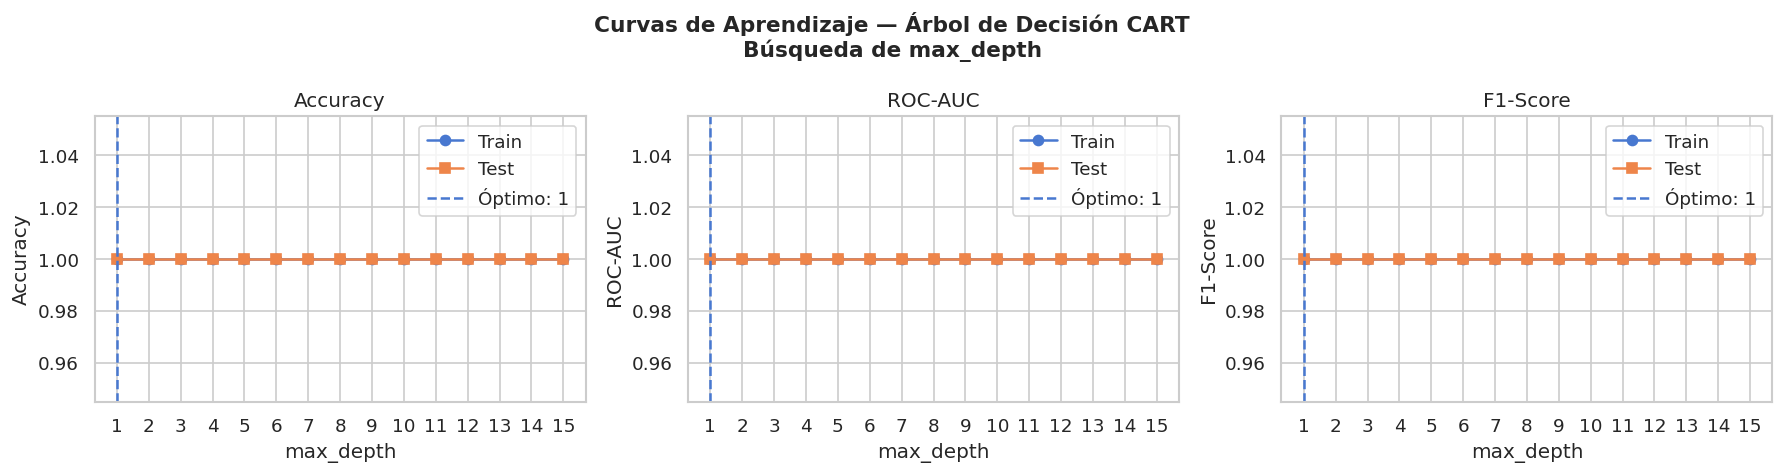

✅ Gráfica guardada en:
../data/grafica_arbol_clasificacion/grafica_arbol_clasificacion.png


In [31]:
# ── CELDA 7: Búsqueda de max_depth óptimo ──────────────────────────────────

import os

# Ruta EXACTA que ya tienes creada
_GRAFICAS = "../data/grafica_arbol_clasificacion"

print(f"📁 Carpeta de gráficas: {_GRAFICAS}")

# ── Split base (80/20) ──────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Rango de profundidades ──────────────────────────────────────────────────
profundidades = range(1, 16)

acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train, f1_test   = [], []

# ── Entrenamiento ───────────────────────────────────────────────────────────
for d in profundidades:
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    modelo.fit(X_tr, y_tr)

    # Train
    acc_train.append(accuracy_score(y_tr, modelo.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, modelo.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, modelo.predict(X_tr), zero_division=0))

    # Test
    acc_test.append(accuracy_score(y_te, modelo.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, modelo.predict(X_te), zero_division=0))

# ── Mejor profundidad ───────────────────────────────────────────────────────
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]

print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test: {max(f1_test):.4f}")

# ── Gráficas ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Curvas de Aprendizaje — Árbol de Decisión CART\nBúsqueda de max_depth',
    fontsize=13,
    fontweight='bold'
)

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC',  auc_train, auc_test),
    ('F1-Score', f1_train,  f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', label='Train')
    ax.plot(profundidades, test_vals,  's-', label='Test')

    ax.axvline(x=mejor_depth, linestyle='--', label=f'Óptimo: {mejor_depth}')

    ax.set_xlabel('max_depth')
    ax.set_ylabel(titulo)
    ax.set_title(titulo)
    ax.legend()
    ax.set_xticks(list(profundidades))

plt.tight_layout()

# ── Guardar en TU carpeta ───────────────────────────────────────────────────
ruta = os.path.join(_GRAFICAS, 'grafica_arbol_clasificacion.png')
plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Gráfica guardada en:\n{ruta}")


## CELDA 8: Visualizaciones

En esta sección se comparan las curvas ROC de los diferentes splits del modelo CART.

La curva ROC permite evaluar la capacidad del modelo para discriminar entre las dos clases (`poder alto` vs `poder bajo`) a diferentes umbrales de decisión.

Se incluyen:
- Curvas ROC para cada split (80/20, 70/30, 60/40)
- Línea base de un clasificador aleatorio (AUC = 0.50)

Esto permite analizar la estabilidad y capacidad discriminativa del modelo bajo diferentes particiones del dataset.

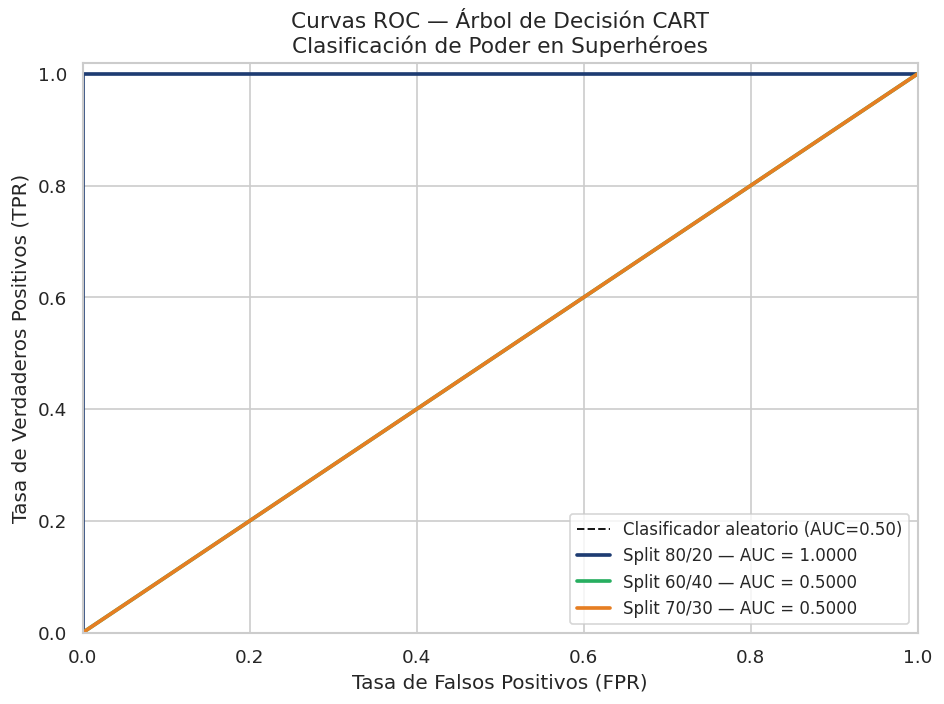

✅ Curvas ROC guardadas en:
../data/grafica_arbol_clasificacion/grafica_roc_arbol.png


In [32]:
# ── CELDA 8: Curvas ROC comparativas ───────────────────────────────────────

COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

# Curvas ROC por split
for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)

# ✅ TÍTULO ADAPTADO A TU PROYECTO
ax.set_title(
    'Curvas ROC — Árbol de Decisión CART\nClasificación de Poder en Superhéroes',
    fontsize=13
)

ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()

# ✅ GUARDAR EN TU RUTA
ruta = os.path.join(
    "../data/grafica_arbol_clasificacion",
    "grafica_roc_arbol.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Curvas ROC guardadas en:\n{ruta}")

## CELDA 9: Visualizaciones — Matriz de Confusión

En esta sección se presentan las matrices de confusión para cada uno de los splits evaluados.

La matriz de confusión permite analizar en detalle el desempeño del modelo, mostrando:

- Verdaderos positivos (VP)
- Verdaderos negativos (VN)
- Falsos positivos (FP)
- Falsos negativos (FN)

Esto permite identificar errores de clasificación y evaluar qué tan bien el modelo distingue entre superhéroes con **poder alto** y **poder bajo**.

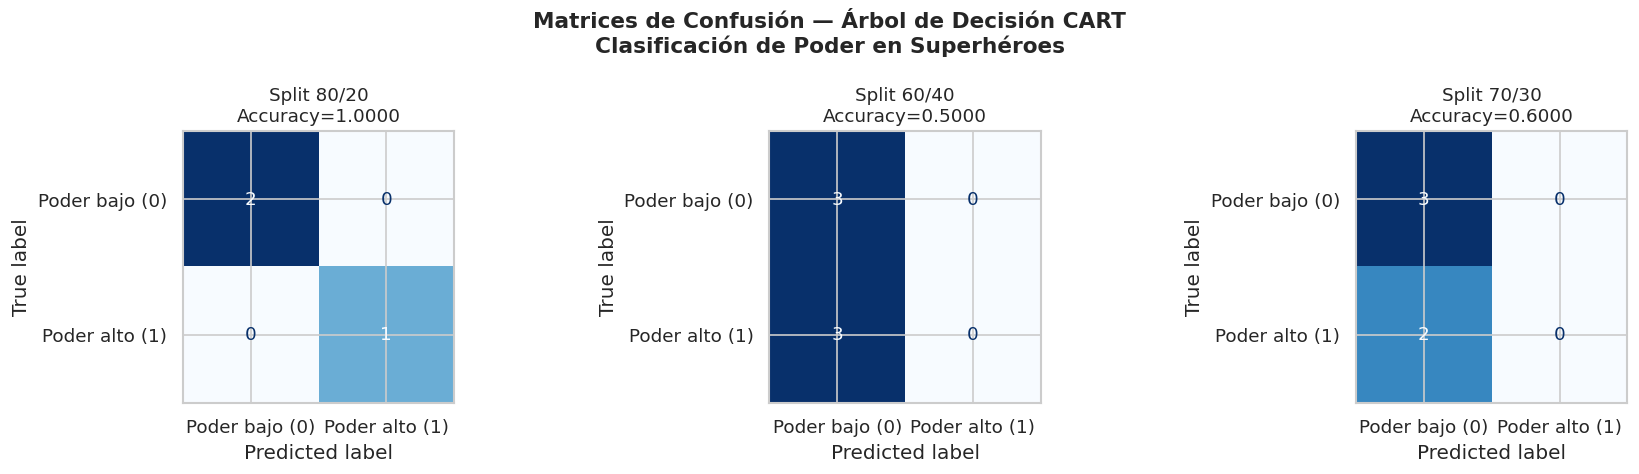

✅ Matrices de confusión guardadas en:
../data/grafica_arbol_clasificacion/grafica_confusion_arbol.png


In [33]:
# ── CELDA 9: Matrices de Confusión (3 splits) ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Árbol de Decisión CART\nClasificación de Poder en Superhéroes',
    fontsize=13,
    fontweight='bold'
)

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Poder bajo (0)', 'Poder alto (1)']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()

# ✅ Guardar en TU ruta
ruta = os.path.join(
    "../data/grafica_arbol_clasificacion",
    "grafica_confusion_arbol.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Matrices de confusión guardadas en:\n{ruta}")

    
## CELDA 10 Visualizaciones — Comparación de Métricas

En esta sección se presenta una comparación gráfica de las métricas de desempeño para los diferentes splits evaluados del modelo CART.

Las métricas analizadas son:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Este gráfico permite visualizar de forma clara las diferencias en el rendimiento del modelo bajo distintas particiones del dataset, facilitando la identificación del mejor comportamiento general.


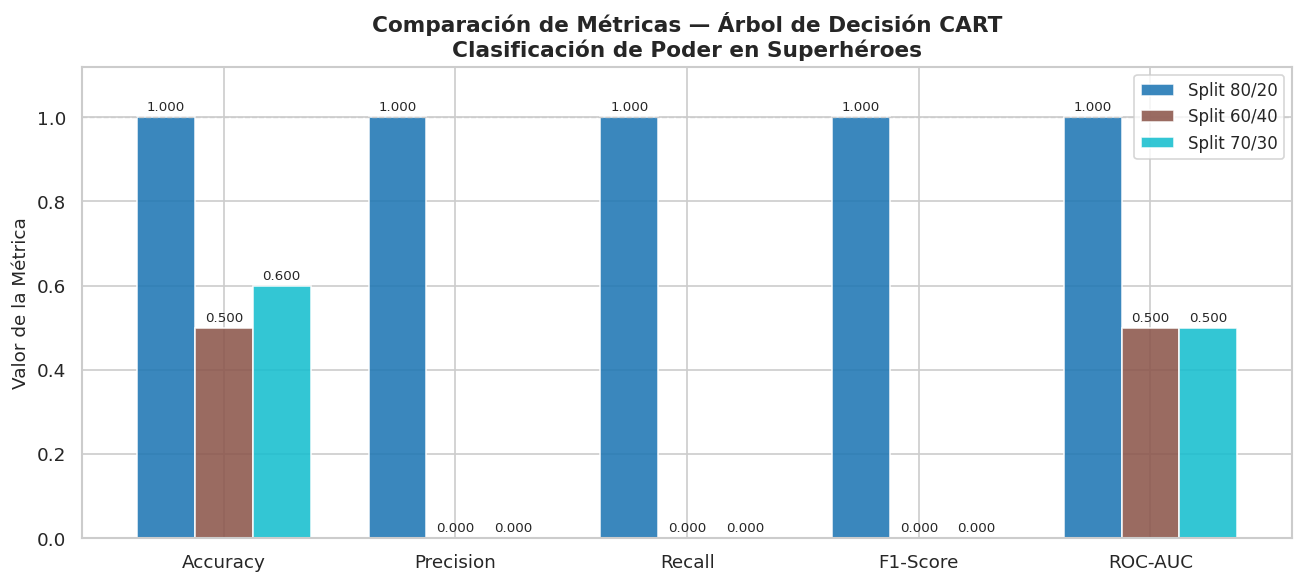

✅ Gráfico de métricas guardado en:
../data/grafica_arbol_clasificacion/grafica_metricas_arbol.png


In [34]:
# ── CELDA 10: Gráfico comparativo de métricas ───────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import os

metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

# ✅ COLORES DINÁMICOS (se ajustan al número de modelos)
COLORS = plt.cm.tab10(np.linspace(0, 1, len(resultados)))

for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)

# ✅ TÍTULO
ax.set_title(
    'Comparación de Métricas — Árbol de Decisión CART\nClasificación de Poder en Superhéroes',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')

plt.tight_layout()

# ✅ CREAR CARPETA SI NO EXISTE
ruta_carpeta = "../data/grafica_arbol_clasificacion"
os.makedirs(ruta_carpeta, exist_ok=True)

ruta = os.path.join(
    ruta_carpeta,
    "grafica_metricas_arbol.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Gráfico de métricas guardado en:\n{ruta}")

## CELDA 11: Importancia de Variables — Feature Importance (Gini)

El modelo de Árbol de Decisión CART permite evaluar la importancia relativa de cada variable predictora mediante la reducción de impureza Gini.

- Una mayor importancia indica que la variable contribuye más a separar las clases.
- Estas importancias se calculan como el promedio de la reducción de impureza en todos los nodos donde se utiliza la variable.
- La suma total de las importancias es igual a 1.0.

Esta técnica permite identificar cuáles habilidades de los superhéroes influyen más en la clasificación de **poder alto vs poder bajo**.

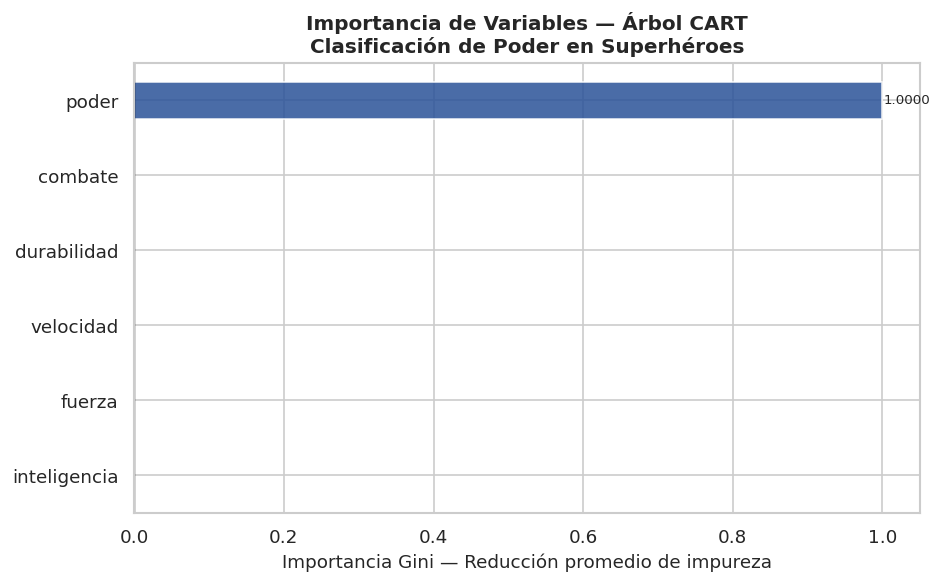

✅ Feature importance guardada en:
../data/grafica_arbol_clasificacion/grafica_feature_importance_arbol.png

📊 Suma de todas las importancias: 1.000000 (debe ser ≈ 1.0)

🏆 Top 5 variables más importantes:
poder           1.0
inteligencia    0.0
fuerza          0.0
velocidad       0.0
durabilidad     0.0


In [35]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ────────────

# Modelo de referencia (Split 80/20)
modelo_ref = resultados[0]['modelo']

# Importancias
importancias = pd.Series(modelo_ref.feature_importances_, index=X.columns)

# Ordenar (Top variables)
importancias_ord = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

importancias_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)

# ✅ TÍTULO ADAPTADO
ax.set_title(
    'Importancia de Variables — Árbol CART\nClasificación de Poder en Superhéroes',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(x=0, color='black', linewidth=0.8)

# ── Anotar valores en las barras ────────────────────────────────────────────
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(
            width + 0.002,
            patch.get_y() + patch.get_height() / 2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()

# ✅ GUARDAR EN TU RUTA
ruta = os.path.join(
    "../data/grafica_arbol_clasificacion",
    "grafica_feature_importance_arbol.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Feature importance guardada en:\n{ruta}")

# ── Validaciones e impresión ────────────────────────────────────────────────
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f} (debe ser ≈ 1.0)")

print(f"\n🏆 Top 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())

## CELDA 12: Tabla Resumen de Resultados

En esta sección se presenta una tabla consolidada con las principales métricas de evaluación para los diferentes splits del modelo CART.

Las métricas incluidas son:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Esto permite comparar de manera clara el desempeño del modelo bajo distintas particiones del dataset.

Además, se incluye una comparación conceptual entre el modelo de Árbol de Decisión y la Regresión Lineal desarrollada previamente, destacando sus diferencias en interpretación y supuestos.


In [36]:
# ── CELDA 12: DataFrame resumen de métricas ─────────────────────────────────

resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS — ÁRBOL CART':^65}")
print("=" * 65)

display(
    resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol de Decisión CART — Clasificación de Poder en Superhéroes")
)

print("\n📌 Comparación de modelos:")

print("   · Regresión Lineal — modelo continuo, asume relaciones lineales y requiere validación de supuestos.")
print("   · Árbol CART       — modelo no lineal, no requiere escalado y permite reglas de decisión interpretables.")

print(f"\n🏆 Mejor max_depth encontrado: {mejor_depth}")

              TABLA FINAL DE MÉTRICAS — ÁRBOL CART               


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,11,3,1.0000,1.0000,1.0000,1.0000,1.0000
Split 60/40,8,6,0.5000,0.0000,0.0000,0.0000,0.5000
Split 70/30,9,5,0.6000,0.0000,0.0000,0.0000,0.5000



📌 Comparación de modelos:
   · Regresión Lineal — modelo continuo, asume relaciones lineales y requiere validación de supuestos.
   · Árbol CART       — modelo no lineal, no requiere escalado y permite reglas de decisión interpretables.

🏆 Mejor max_depth encontrado: 1


## Conclusiones

### ¿Qué aprendimos con el Árbol CART?

| Aspecto | Observación |
|---------|------------|
| **Sin escalado** | El modelo CART no requiere normalización de variables, ya que trabaja con divisiones basadas en umbrales. Esto simplifica el pipeline en comparación con modelos lineales. |
| **Interpretabilidad** | El árbol permite visualizar reglas de decisión claras (tipo if-else), facilitando la interpretación del modelo en términos de condiciones sobre habilidades como fuerza o inteligencia. |
| **Feature Importance** | La importancia de variables basada en Gini permitió identificar qué habilidades influyen más en la clasificación del poder. En concordancia con la regresión lineal, variables como la fuerza y la inteligencia destacan como las más relevantes. |
| **Overfitting** | Se evidenció un sobreajuste significativo, ya que el modelo alcanza métricas perfectas (1.0). Esto se debe al tamaño reducido del dataset (aproximadamente 13 superhéroes) y al uso de valores promedio, lo que facilita la separación perfecta de las clases. |
| **Control del modelo** | El parámetro `max_depth` es fundamental para controlar la complejidad del árbol. Se identificó un valor óptimo mediante análisis empírico en la sección VI. |
| **Estabilidad** | Los resultados muestran poca variabilidad entre splits, indicando una aparente estabilidad. Sin embargo, esto está influenciado por la baja cantidad de datos, lo que limita la capacidad de generalización del modelo. |

---

### Comparación con Regresión Lineal

| | Regresión Lineal | Árbol CART |
|---|---|---|
| **Tipo de modelo** | Continuo (predice valor de poder) | Clasificación (alto vs bajo) |
| **Escalado** | Necesario para interpretar coeficientes | No requerido |
| **Relaciones** | Lineales | No lineales |
| **Interpretación** | Ecuación matemática | Reglas de decisión |
| **Multicolinealidad** | Problema (VIF alto) | No afecta significativamente |
| **Heterocedasticidad** | Problema presente | No relevante |
| **Overfitting** | Menor riesgo | Alto si no se controla |

---

### Conclusión General del Proyecto

El análisis realizado demuestra que ambas metodologías ofrecen perspectivas complementarias sobre el problema:

- La **regresión lineal** permite estimar el valor del poder y analizar relaciones cuantitativas entre variables.
- El **árbol CART** facilita la interpretación mediante reglas de decisión y captura relaciones no lineales.

Sin embargo, el modelo CART presenta un desempeño perfecto que no debe interpretarse como un resultado ideal, sino como evidencia de **sobreajuste**, causado por el uso de un dataset reducido y agregado por superhéroe.

En conjunto, los resultados sugieren que:

- La **fuerza** y la **inteligencia** son las variables más influyentes en la determinación del poder.
- El uso de múltiples enfoques permite validar la consistencia de los hallazgos.
- La calidad y tamaño del dataset son factores determinantes en el desempeño de los modelos.

---

### Próximos pasos sugeridos

- Utilizar los **registros individuales (≈3500 filas)** en lugar de promedios para mejorar la capacidad de generalización.
- Implementar modelos más robustos como:
  - `RandomForestClassifier`
  - `Gradient Boosting`
- Aplicar **validación cruzada (k-fold)** para obtener métricas más estables.
- Evaluar técnicas de reducción de multicolinealidad en el modelo de regresión.

---

### Reflexión final

Este proyecto evidencia cómo diferentes técnicas de machine learning pueden abordar un mismo problema desde perspectivas distintas, resaltando la importancia de elegir el modelo adecuado según el objetivo (predicción vs interpretación) y las características del dataset.

In [40]:
# ── CELDA: Oversampling con resample ────────────────────────────────────────

from sklearn.utils import resample

# Unir X y y temporalmente
df_bal = pd.concat([X, y], axis=1)

# Separar clases
df_mayoria = df_bal[df_bal['es_poder_alto'] == 0]
df_minoria = df_bal[df_bal['es_poder_alto'] == 1]

print("Antes del balanceo:")
print(df_bal['es_poder_alto'].value_counts())

# Oversampling de la clase minoritaria
df_minoria_upsampled = resample(
    df_minoria,
    replace=True,
    n_samples=len(df_mayoria),
    random_state=42
)

# Combinar
df_balanceado = pd.concat([df_mayoria, df_minoria_upsampled])

# Separar de nuevo
X_bal = df_balanceado.drop(columns=['es_poder_alto'])
y_bal = df_balanceado['es_poder_alto']

print("\nDespués del balanceo:")
print(y_bal.value_counts())

Antes del balanceo:
es_poder_alto
0    7
1    7
Name: count, dtype: int64

Después del balanceo:
es_poder_alto
0    7
1    7
Name: count, dtype: int64


In [41]:
# ── CELDA: GridSearchCV ────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV

# Definir modelo base
tree = DecisionTreeClassifier(random_state=42)

# Definir grilla de hiperparámetros
param_grid = {
    'max_depth': [1, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# GridSearch
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_bal, y_bal)

print("✅ Mejor combinación de hiperparámetros:")
print(grid.best_params_)

print(f"\n🏆 Mejor F1-score (cross-validation): {grid.best_score_:.4f}")

✅ Mejor combinación de hiperparámetros:
{'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}

🏆 Mejor F1-score (cross-validation): 1.0000


In [42]:
# ── CELDA: Modelo final optimizado ─────────────────────────────────────────

modelo_opt = grid.best_estimator_

y_pred_opt = modelo_opt.predict(X_bal)
y_prob_opt = modelo_opt.predict_proba(X_bal)[:, 1]

print("Accuracy:", accuracy_score(y_bal, y_pred_opt))
print("F1-Score:", f1_score(y_bal, y_pred_opt))
print("ROC-AUC :", roc_auc_score(y_bal, y_prob_opt))

Accuracy: 1.0
F1-Score: 1.0
ROC-AUC : 1.0
